# Business Context:
Nova Bank must optimize a core lending trade-off: maximize loan growth while minimizing credit losses. The bank currently serves borrowers across the USA, UK, and Canada through multiple lending products, but default risk varies significantly across customer profiles.

This analysis focuses on identifying high-risk borrower segments, understanding the main drivers of default, and developing a risk segmentation framework to improve underwriting decisions and portfolio quality.

The portfolio comprises approximately 32,000 personal loans. Target variable: loan_status (Default/Non-default). The current default rate is 21.8%—notably above the 15–20% range commonly cited as elevated risk for personal lending portfolios, signaling a need to identify and address the drivers of default.

# Analysis Approach:
Data Cleaning → Univariate Overview → Bivariate → Multivariable Cross-tab → Risk Scoring → Insights & Recommendations

# Key Questions:
- Which types of borrowers are more likely to default?
- Do certain loan purposes (education, medical, personal, debt consolidation) carry more risk?
- How do loan-to-income and debt-to-income ratios relate to repayment?
- Does employment type or home ownership make a difference?
- How do past defaults or longer credit histories affect loan outcomes?
- Are there clear differences between borrowers in the USA, UK, and Canada?
- Which loan grades or terms seem safer, and which are riskier?
- Can groups of borrowers be identified that look “safe” versus “risky”?

## LOAD LIBRARIES AND DATASET

In [1]:
# ── Libraries ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.family']        = 'sans-serif'

# ── Colors ──────────────────────────────────────────────
PALETTE  = {'Non-default': '#2AD992', 'Default': '#845EC2'}
C_SAFE   = '#2AD992'
C_RISK   = '#845EC2'
C_WARN   = '#FF6B6B'

# ── Function: default rate table ───────────────────────────
def default_rate(df, col):
    t = pd.crosstab(df[col], df['loan_status'])
    t['default_rate_%'] = (t['Default'] / t.sum(axis=1) * 100).round(2)
    return t.sort_values('default_rate_%', ascending=False)

# ── Function: bar chart default rate ──────────────────────
def plot_default_rate(df, col, ax, title='', order=None):
    rate = default_rate(df, col)['default_rate_%']
    if order: rate = rate.reindex(order)
    colors = [C_WARN if v > 25 else '#60A5FA' if v > 15 else C_SAFE for v in rate]
    bars = ax.bar(rate.index.astype(str), rate.values, color=colors)
    ax.axhline(21.8, color='gray', linestyle='--', linewidth=1, label='Portfolio avg (21.8%)')
    for b, v in zip(bars, rate.values):
        ax.text(b.get_x() + b.get_width()/2, v+0.5, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

# ── Load data ────────────────────────────────────────────
credit_df = pd.read_excel("Credit_Risk_Dataset_Onyx_Data_September_25.xlsx")
credit_df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


## Understand the data:
- **client_ID**: Unique identifier for each client
- **person_age**: Age of the applicant (years).
- **person_income**: Annual income of the applicant (USD).
- **person_home_ownership**: Home ownership status (RENT/OWN/MORTGAGE)
- **person_emp_length**: Employment length (years)
- **loan_intent**: Purpose of the loan (PERSONAL, MEDICAL, EDUCATION, etc.)
- **loan_grade**: Credit grade assigned to the loan (A–G)
- **loan_amnt**: Requested loan amount (USD)
- **loan_int_rate**: Loan interest rate (%)
- **loan_status**: Loan repayment status (0 = non-default, 1 = default) -> This is the target for this analysis
- **loan_percent_income**: Percentage of income allocated to loan repayment
- **cb_person_default_on_file**: Whether applicant has defaulted previously (Y/N)
- **cb_person_cred_hist_length**: Length of credit history (years)
- **gender**: Gender of applicant (Male/Female)
- **marital_status**: Marital status (Single/Married/Divorced/Widowed)
- **education_level**: Education level (High School/Bachelor/Master/PhD)
- **country**: Country of residence
- **state**: State/Province of residence
- **city**: City of residence
- **city_latitude**: Latitude coordinate of the city
- **city_longitude**: Longitude coordinate of the city
- **employment_type**: Employment type (Full-time/Part-time/Self-employed/Unemployed)
- **loan_term_months**: Loan term in months (12, 24, 36, 60)
- **loan_to_income_ratio**: Loan amount divided by applicant income
- **other_debt**: Simulated additional debt held by applicant (USD)
- **debt_to_income_ratio**: Total debt obligations divided by applicant income
- **open_accounts**: Number of open credit accounts
- **credit_utilization_ratio**: Credit utilization ratio (0–1)
- **past_delinquencies**: Number of past delinquencies/late payments

## Exploratory Data Analysis

In [2]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [3]:
credit_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,45.407613,-63.805473,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,7.644809,46.615580,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000


In [4]:
# ── Basic info ────────────────────────────────────────
original_shape = credit_df.shape
print("Shape:", original_shape)
print("Duplicates:", credit_df.duplicated().sum())

# ── Missing values ────────────────────────────────────
missing = credit_df.isna().sum()
missing_pct = (missing / len(credit_df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
display(missing_df[missing_df['count'] > 0].sort_values('count', ascending=False))

# ── Outlier logic checks ──────────────────────────────
print(f"\nAge > 100: {(credit_df['person_age'] > 100).sum()}")
print(f"Emp_length > 60: {(credit_df['person_emp_length'] > 60).sum()}")
print(f"Emp > Age-15 (impossible): {(credit_df['person_emp_length'] > credit_df['person_age']-15).sum()}")
print(f"Credit hist > Age (impossible): {(credit_df['cb_person_cred_hist_length'] > credit_df['person_age']).sum()}")

Shape: (32581, 29)
Duplicates: 0


,count,pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75



Age > 100: 5
Emp_length > 60: 2
Emp > Age-15 (impossible): 2
Credit hist > Age (impossible): 0


## Data cleaning

In [5]:
# ── Remove impossible records ────────────────────────────
print(f"Shape before: {credit_df.shape}")
print(f"Rows removed (age>100): {(credit_df['person_age'] > 100).sum()}")
print(f"Rows removed (emp>60): {(credit_df['person_emp_length'] > 60).sum()}")
print(f"Rows removed (emp > age-15): {(credit_df['person_emp_length'] > credit_df['person_age']-15).sum()}")
credit_df = credit_df[credit_df['person_age'] <= 100]
credit_df = credit_df[~(credit_df['person_emp_length'] > 60)]
credit_df = credit_df[~(credit_df['person_emp_length'] > credit_df['person_age'] - 15)]
credit_df = credit_df[~(credit_df['cb_person_cred_hist_length'] > credit_df['person_age'])]

# Drop 'loan_percent_income' because Correlation between 'loan_percent_income' vs 'loan_to_income_ratio' = 1.00 — perfect duplicate. 
credit_df = credit_df.drop(columns='loan_percent_income', axis=1)

# ── Impute median by loan_grade for loan_int_rate ─────
credit_df['loan_int_rate'] = credit_df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))

# Fill person employee length
credit_df['person_emp_length'] = credit_df['person_emp_length'].fillna(0)

# ── Encode target ────────────────────────────────────────
credit_df['loan_status'] = np.where(credit_df['loan_status'] == 1, 'Default', 'Non-default')

print(f"Cleaned shape: {credit_df.shape} | Missing remaining: {credit_df.isna().sum().sum()}")

Shape before: (32581, 29)
Rows removed (age>100): 5
Rows removed (emp>60): 2
Rows removed (emp > age-15): 2
Cleaned shape: (32574, 28) | Missing remaining: 0


## UNIVARIATE OVERVIEW

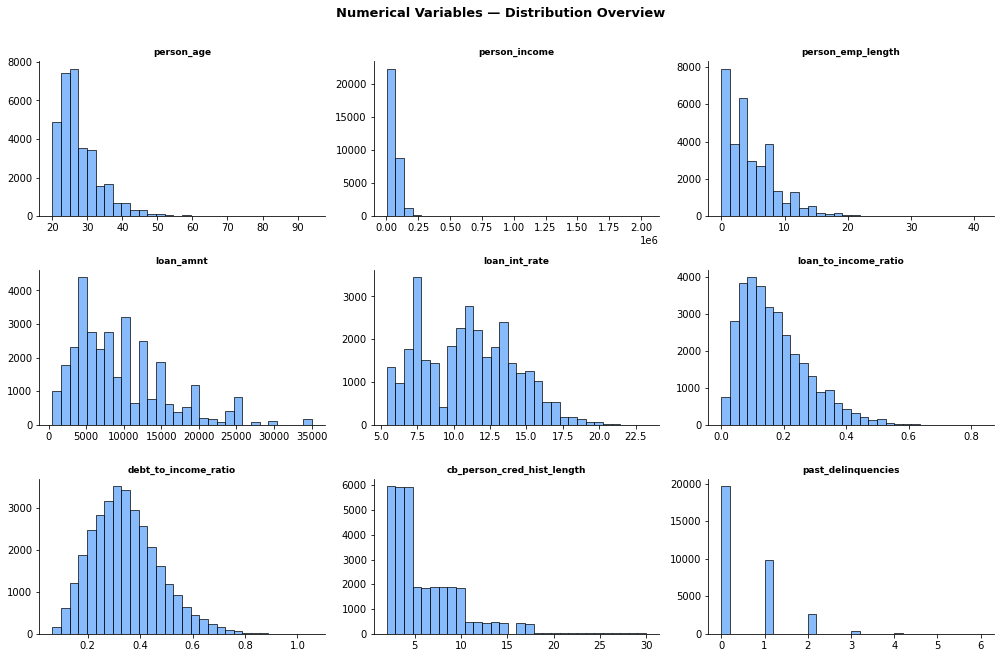

In [6]:
# ── Numerical overview — 1 grid ──────────────────────────
num_cols = ['person_age', 'person_income', 'person_emp_length',
             'loan_amnt', 'loan_int_rate', 'loan_to_income_ratio',
             'debt_to_income_ratio', 'cb_person_cred_hist_length','past_delinquencies']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(credit_df[col].dropna(), ax=axes[i], color='#60A5FA', bins=30)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Numerical Variables — Distribution Overview',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

- **person_age:** Right-skewed distribution, with the peak concentrated between ages 22 and 27. The count drops rapidly after age 35 and becomes negligible from age 60 onwards. The 20–30 age group represents a segment potentially associated with higher risk.
- **person_income:** Heavily right-skewed distribution; over 80% of observations are concentrated below 250K, while the tail extends to 2M. This indicates significant outliers—some customers report incomes in the millions of dollars, whereas the dataset consists of small consumer loans (average 9,588).
- **person_emp_length:** Bimodal distribution with two distinct peaks: the highest at 0–1 years (~7,800 observations) and a secondary peak at 4–5 years. The group with 0 years of experience accounts for an unusually large proportion—likely recent graduates or individuals who have just changed jobs.
- **loan_amnt:** Multimodal distribution with clear clusters at 5,000, 10,000, 15,000, 20,000, and 25,000. Customers tend to borrow in fixed increments.
- **loan_int_rate:** Distribution is relatively more symmetrical than other variables, concentrated between 7% and 15%, with a bimodal pattern peaking around 7.5% and 13%. This suggests the existence of two distinct product groups.
- **loan_to_income_ratio (LTI):** Right-skewed distribution, heavily concentrated between 0.05 and 0.25, with a tail extending to 0.8. The majority of customers borrow less than 25% of their annual income—a safe level. However, the upper tail (0.4 and above) — while small in volume — shows a spread of 34.7 percentage points. Preliminary observation suggests LTI above 30–50% may warrant a hard threshold; this is validated in Q3.
- **debt_to_income_ratio (DTI):** Symmetrical distribution (approximating a normal distribution), peaking around 0.3–0.4. This variable exhibits the "healthiest" distribution in the entire dataset—minimal outliers and low skewness. However, attention should be paid to the upper tail starting at 0.6 (~several hundred observations): these customers are allocating over 60% of their income to debt repayment, indicating a very high probability of default regardless of other factors. This serves as a typical hard rejection threshold in standard underwriting.
- **cb_person_cred_hist_length:** Strongly right-skewed distribution, concentrated between 2 and 5 years of credit history, then tapering off up to 30 years. This is entirely consistent with the dataset's younger demographic profile. A short credit history does not necessarily imply high risk; however, when combined with high LTI and DTI, it becomes a danger signal due to the lack of sufficient tracking data to assess long-term repayment behavior.
- **past_delinquencies:** Extremely right-skewed distribution; ~19,000 observations show zero instances of late payment, with a sharp drop-off thereafter. This is a classic zero-inflated variable—it cannot be used directly in a continuous format..

In [7]:
# ── Create band features ─────────────────────────────────
credit_df['age_band']  = pd.cut(credit_df['person_age'],
    bins=[0,20,25,30,35,40,45,50,100], labels=['0-20','20-25','25-30','30-35','35-40','40-45','45-50','> 50'])
credit_df['income_band']  = pd.qcut(credit_df['person_income'], q=5,
    labels=['Low','Lower-mid','Mid','Upper-mid','High'], duplicates='drop')
credit_df['emp_band']    = pd.cut(credit_df['person_emp_length'],
    bins=[0,2,5,10,100], labels=['0-2yr','3-5yr','6-10yr','>10yr'])
credit_df['loan_amnt_band']  = pd.cut(credit_df['loan_amnt'],
    bins=[0,5000,10000,20000,50000], labels=['0-5K','5-10K','10-20K','> 20K'])
credit_df['dti_band']    = pd.cut(credit_df['debt_to_income_ratio'],
    bins=[0,0.3,0.5,0.7,0.85,1.06], labels=['0-30%','30-50%','50-70%','70-85%','> 85%'])
credit_df['lti_band']    = pd.cut(credit_df['loan_to_income_ratio'],
    bins=[0,0.3,0.5,0.7,0.85,1.06], labels=['0-30%','30-50%','50-70%','70-85%','> 85%'])
credit_df['rate_band']   = pd.cut(credit_df['loan_int_rate'],
    bins=[5,8,11,14,17,24], labels=['5-8%','8-11%','11-14%','14-17%','> 17%'])

## DRIVEN BIVARIATE ANALYSIS
### Q1. Which types of borrowers are most likely to default?

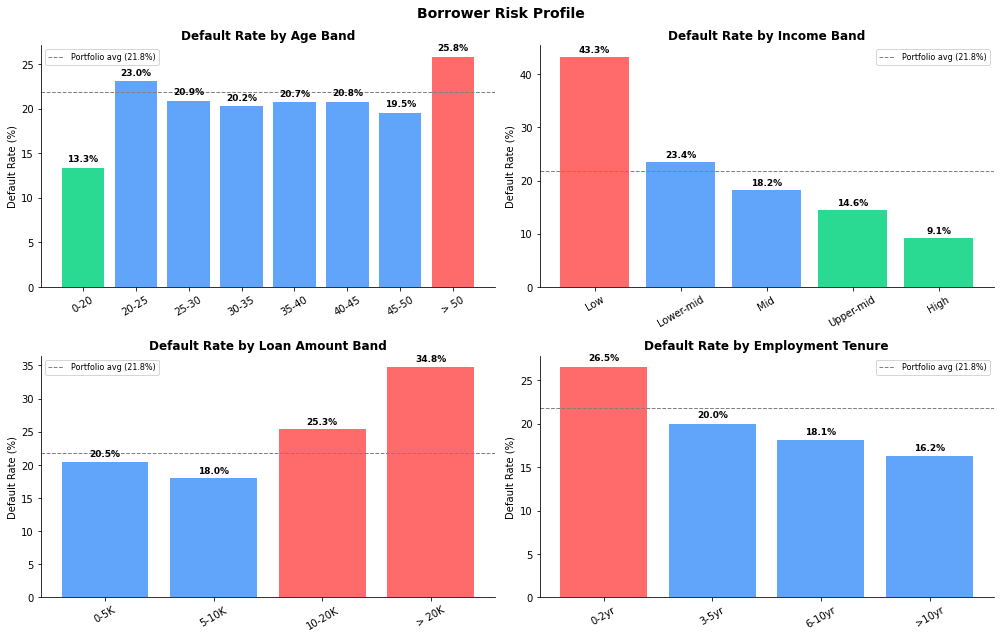

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_default_rate(credit_df, 'age_band', axes[0,0],
    'Default Rate by Age Band',
    order=['0-20','20-25','25-30','30-35','35-40','40-45','45-50','> 50'])

plot_default_rate(credit_df, 'income_band', axes[0,1],
    'Default Rate by Income Band',
    order=['Low','Lower-mid','Mid','Upper-mid','High'])

plot_default_rate(credit_df, 'loan_amnt_band', axes[1,0],
    'Default Rate by Loan Amount Band',
    order=['0-5K','5-10K','10-20K','> 20K'])

plot_default_rate(credit_df, 'emp_band', axes[1,1],
    'Default Rate by Employment Tenure',
    order=['0-2yr','3-5yr','6-10yr','>10yr'])

plt.suptitle('Borrower Risk Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### The 4 highest-risk borrower groups
- **age_band**: 
    - `The under-20 group` (13.3%) sits 8.5 percentage points below the portfolio average—a figure that looks promising but warrants caution: this group is small, involves smaller loans, and lacks sufficient history to reveal true risk. This may reflect survivorship bias rather than a genuine indicator of safety. 
    - `The 20–25 group` (23.0%) immediately exceeds the portfolio average; as the largest segment in the dataset, even a margin of just 1.2 percentage points above the average translates to the highest absolute number of defaults across the entire portfolio. `The 25–50 group` hovers between 20% and 21%, closely tracking the portfolio average—showing no distinct signals, this group serves as the portfolio's "baseline." 
    - `The >50 group` (25.8%) presents the most notable anomaly: it is 4 percentage points above the average, breaking the downward trend observed in `the 45–50 group`. It is highly likely that this group borrows for different purposes (e.g., medical expenses, retirement income gaps) and relies on fixed income, resulting in less flexible repayment capacity. Cross-referencing loan intent and income brackets for the >50 group is necessary.

- **income_band**: This chart displays the most distinct and consistent gradient among the four—the default rate drops steadily from 43.3% to 9.1% as income rises, with no exceptions. This provides the strongest evidence that income is a highly discriminating and monotonic variable—ideal characteristics for a scorecard variable.

    - `The Low group` (43.3%) has a default rate double the portfolio average; nearly 4.3 out of every 10 low-income borrowers default. This goes beyond mere risk; it represents a predictable loss. Management should ask: what percentage of the current portfolio is lent to this group, and is the pricing sufficient to offset these losses?

    - Regarding the `High income group` (9.1%): even the highest-income customers exhibit a relatively high default rate, suggesting that income should be combined with LTI or DTI metrics to better screen for risk within this segment.
    
- **loan_amnt_band**: The pattern shows a monotonic increase relative to loan size is `the 5–10K group` has the lowest Default Rate at 18.0%, whereas `the >20K group` surges to 34.8%—nearly double that of the safest cohort.

    - Interestingly, `the 0–5K group` (20.5%) exhibits a higher rate than `the 5–10K group` (18.0%), defying standard linear logic. This may stem from the fact that very small loans often involve borrowers who do not qualify for larger amounts (due to low income or weak credit history), resulting in a high DR despite the small principal; this represents an adverse selection effect within the micro-loan segment.

    - `The >20K group` (34.8%) exceeds the portfolio average by 13 percentage points, marking a segment that requires mandatory manual review or additional collateral. Cross-referencing with Q7 and Q8 confirms: the >20K loan amount group skews heavily toward Grade D+ and Low-Mid income — two factors individually associated with DR above 50%. This double-risk zone (large loan + poor grade) is addressed directly by Rule R1 in the underwriting policy.
    
- **emp_band**: There is a monotonically decreasing trend based on tenure: the longer the employment, the lower the Default Rate (DR). This pattern is consistent and aligns with clear business logic—individuals with stable, long-term employment have more predictable incomes and are less susceptible to sudden unemployment shocks.

    - `The 0–2 year group` (27.4%) exceeds the average by 5.6 percentage points and constitutes the largest segment of the dataset (according to the distribution chart). This represents a risky combination: a large population size coupled with a high DR.

    - The gap between `the 0–2 year` and `3–5 year groups` is 7.4 percentage points, whereas the difference between `the 3–5 year` and `6–10 year groups` is only 1.9 percentage points; this suggests that the 3-year mark is the most critical inflection point. Approval policies should prioritize the ≥3-year threshold rather than relying on a continuous scoring scale.

### Q2. Do certain loan purposes carry higher risk?

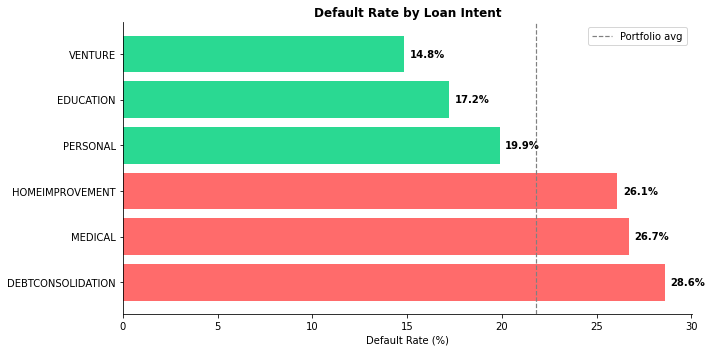

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

rate = default_rate(credit_df, 'loan_intent')['default_rate_%']
colors = [C_WARN if v > 25 else '#60A5FA' if v > 20 else C_SAFE for v in rate]
bars = ax.barh(rate.index, rate.values, color=colors)
ax.axvline(21.8, color='gray', linestyle='--', linewidth=1.2, label='Portfolio avg')
for b, v in zip(bars, rate.values):
    ax.text(v+0.3, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Loan Intent', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Clear divergence in loan intentions
- `Debt Consolidation` (28.6%) > `Medical` (26.7%) > `Home Improvement` (26.1%) — all three exceed the average and do NOT generate new income for debt repayment. This constitutes "defensive borrowing"—borrowing to address existing issues rather than for future investment.

- `Venture` (14.8%) and `Education` (17.2%) are the safest categories. `Venture` borrowers possess business plans, while `Education` borrowers typically see their income rise over time.

**Business Implication**: **Loan intent** shows a 13.8 pp spread — moderate discriminatory power. It is not used as a standalone rejection rule because intent is self-reported and easily manipulated, and much of the apparent signal is absorbed by income and grade. However, it functions as a valid risk modifier: borrowers citing `Debt Consolidation` or `Medical` purposes should face DTI caps 5 pp lower than standard thresholds, as these intents signal existing financial stress rather than forward-looking investment.

**Action**: For `Debt Consolidation` and `Medical` loans, require additional income verification and set a DTI cap 5 percentage points lower than that for other loan intents.

### Q3. How do LTI and DTI relate to repayment?

posx and posy should be finite values
posx and posy should be finite values


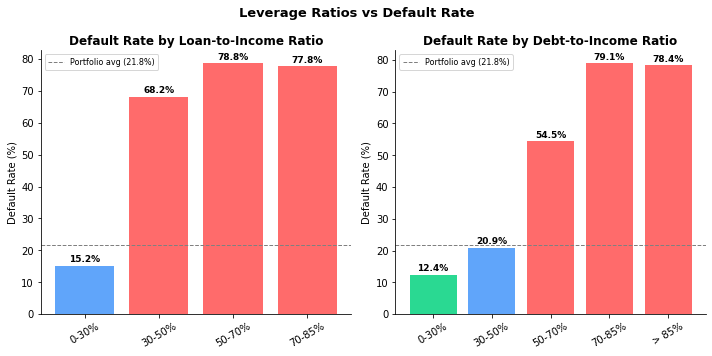

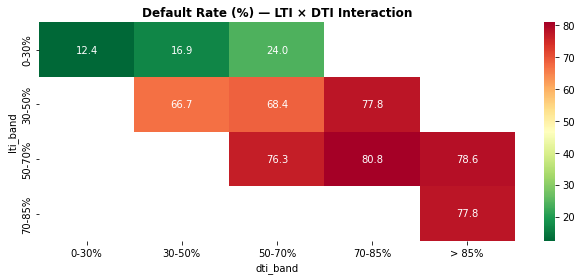

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_default_rate(credit_df, 'lti_band', axes[0],
    'Default Rate by Loan-to-Income Ratio',
    order=['0-30%','30-50%','50-70%','70-85%','> 85%'])

plot_default_rate(credit_df, 'dti_band', axes[1],
    'Default Rate by Debt-to-Income Ratio',
    order=['0-30%','30-50%','50-70%','70-85%','> 85%'])

plt.suptitle('Leverage Ratios vs Default Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Combination effect — pivot table
pivot_q3 = credit_df.assign(default_flag=(credit_df['loan_status']=='Default').astype(int))
pivot_q3 = pd.pivot_table(pivot_q3, values='default_flag',
    index='lti_band', columns='dti_band', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9,4))
sns.heatmap(pivot_q3.round(1), annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=ax)
ax.set_title('Default Rate (%) — LTI × DTI Interaction', fontweight='bold')
plt.tight_layout()
plt.show()

- LTI (Loan-to-Income Ratio):
    - `The 30%` threshold marks an extremely sharp "break point"—the Default Rate jumps from 15.2% to 68.2% across just one band, a 53-percentage-point increase in a single step. This represents the largest gap between any two adjacent bands in the entire analysis. Business implication: once the loan amount exceeds 30% of annual income, repayment capacity collapses abruptly, as customers are forced to sacrifice essential spending to service the debt.
    - `The 50–70% band` (78.8%) and the 70–85% band (77.8%) show nearly identical rates; the DR has plateaued and ceases to rise even as the LTI increases further. This suggests that an LTI `above 50%` represents a "broken" zone regarding repayment capacity, rendering further segmentation within this range practically irrelevant for policy purposes. A single, hard threshold at `LTI = 30%` could replace the entire, more complex banding logic.
- DTI (Debt-to-Income Ratio):
    - The DTI metric exhibits two distinct jumps rather than one: the first at `the 50%` threshold (20.9% → 54.5%, a +33.6 percentage point increase) and the second at `the 70%` threshold (54.5% → 79.1%, a +24.6 percentage point increase). This step-like pattern reveals three clear behavioral zones: safe (0–50%), warning (50–70%), and high-risk (>70%).
    - `The 0–30% band` (12.4%) represents the safest zone across the entire portfolio, sitting nearly 10 percentage points below the portfolio average. This segment warrants preferential interest rates or credit limits to drive acquisition and retention.
- LTI × DTI Interaction Heatmap: positive correlation between LTI and DTI—borrowers with high loan amounts relative to income often carry a heavy total debt load as well.
    - The "safe" green zone (top-left corner): `The LTI 0–30% × DTI 0–30% segment` shows a Default Rate of 12.4%—the lowest on the entire heatmap. `The LTI 0–30% × DTI 30–50% segment` remains at a healthy 16.9%. `The LTI 0–30% × DTI 50–70% segment` rises to 24.0%—exceeding the portfolio average but not showing a drastic spike. This demonstrates that a low LTI can somewhat buffer the impact of a moderate DTI.
    - The "danger" red zone (starting from the LTI 30–50% band): Once LTI exceeds 30%, all cells turn deep red; the Default Rate hits 66.7% for `LTI 30–50% × DTI 30–50%`, 68.4% for `LTI 30–50% × DTI 50–70%`, and 77.8% for `LTI 30–50% × DTI 70–85%`. The variance between cells within the same LTI band is less significant than the gap between the `LTI 0–30%` and `LTI 30–50% band`s—reaffirming that the 30% LTI threshold is a more critical determinant of overall risk than DTI.
    - The LTI 50–70% zone (third row): DRs range from 76.3% to 80.8%, with no cell falling below 75%. Once a customer borrows more than 50% of their income—combined with any DTI level from moderate upwards—a default becomes almost certain. 
    - `LTI 70–85% × DTI >85%` (77.8%): This is the single cell in the bottom-right corner—representing the most extreme combination observed in the dataset. The Default Rate of 77.8% is not significantly higher than that of neighboring cells, again suggesting a saturation effect: beyond a certain threshold, increasing leverage does not lead to a substantial rise in Default Rate, as the probability of default was already close to 100%.

## Consolidated policy recommendations

Three findings requiring immediate implementation in the approval rule engine:

- Rule 1 — Hard rejection: LTI ≥ 30% combined with DTI ≥ 50% → Default Rate of 66–81%; no income level or credit grade can salvage this profile.

- Rule 2 — Hard LTI threshold: Mandate LTI < 30% for all standard loans. Customers with LTI between 30% and 50% are eligible for consideration only if DTI < 30% and Credit Grade ≤ C.

- Rule 3 — Priority "Green Zone": The LTI < 30% + DTI < 50% segment exhibits a Default Rate of 12–17%; this group should be fast-tracked for approval and offered preferential products to boost conversion rates within this safe zone.

### Q4. Employment type vs Home ownership — which matters more?

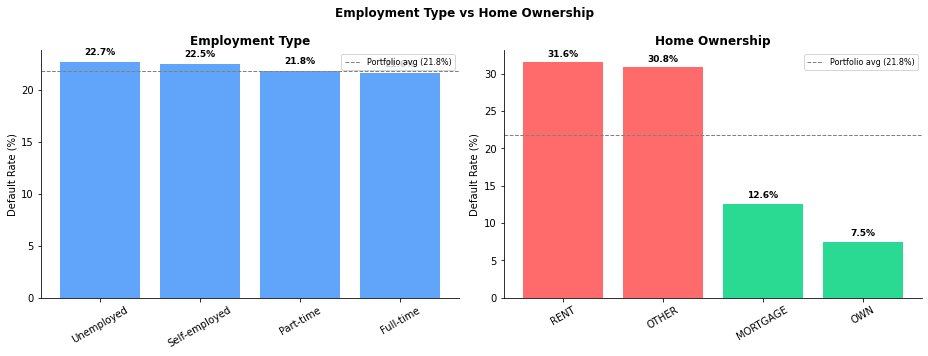

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_default_rate(credit_df, 'employment_type', axes[0], 'Employment Type')
plot_default_rate(credit_df, 'person_home_ownership', axes[1], 'Home Ownership')
plt.suptitle('Employment Type vs Home Ownership', fontweight='bold')
plt.tight_layout()
plt.show()

**Employment type**: `Full-time` **21.6%** vs. `Unemployed` **22.7%** — a difference of only **1.1%**. No practical significance. Do NOT use as an underwriting filter.

**Home ownership**: `OWN` **7.5%** vs. `RENT` **31.6%** — a **4.2x** difference. This is the best proxy for financial stability and asset base.

**Why is employment type a weak signal?** In this dataset, unemployed borrowers still have income from other sources (savings, investments, spouse's income). Employment type fails to capture the full income picture—whereas income_band does.

**Action**: Exclude **employment_type** from the risk model. Retain **person_home_ownership** as a key feature.

### Q5. How do past defaults and credit history affect outcomes?

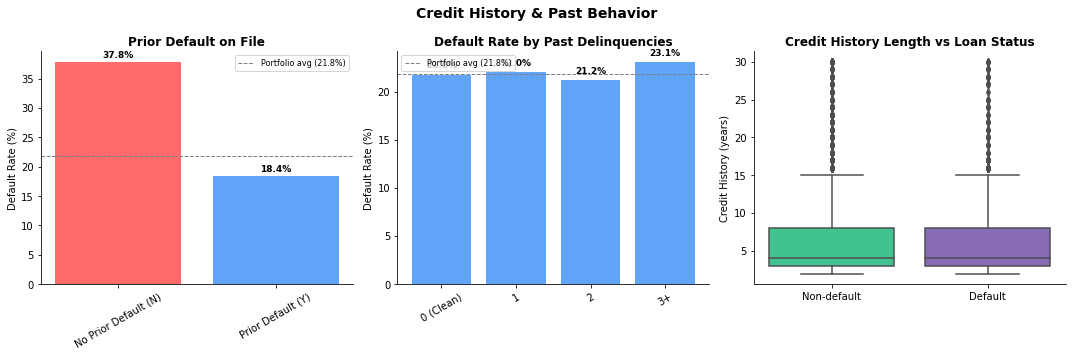


Credit History — Median by group:
loan_status
Default        4.0
Non-default    4.0
Name: cb_person_cred_hist_length, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prior default flag
plot_default_rate(credit_df, 'cb_person_default_on_file', axes[0],
    'Prior Default on File')
axes[0].set_xticklabels(['No Prior Default (N)', 'Prior Default (Y)'])

# Past delinquencies — buckets
credit_df['delinq_band'] = pd.cut(credit_df['past_delinquencies'],
    bins=[-1,0,1,2,10],
    labels=['0 (Clean)', '1', '2', '3+'])
plot_default_rate(credit_df, 'delinq_band', axes[1],
    'Default Rate by Past Delinquencies',
    order=['0 (Clean)', '1', '2', '3+'])

# Credit history length — compare 2 groups
sns.boxplot(data=credit_df, x='loan_status', y='cb_person_cred_hist_length',
    ax=axes[2], palette=PALETTE, order=['Non-default', 'Default'])
axes[2].set_title('Credit History Length vs Loan Status', fontweight='bold')
axes[2].set_ylabel('Credit History (years)')
axes[2].set_xlabel('')

plt.suptitle('Credit History & Past Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print numbers
print("\nCredit History — Median by group:")
print(credit_df.groupby('loan_status')['cb_person_cred_hist_length'].median())

- **Prior default** is the most actionable binary signal across the entire analysis: Y → 37.8% vs. N → 18.4% (2.05×). It costs only a credit file pull to verify and should be the first gate in the underwriting pipeline — checked before income verification, before grade assessment, before any document request.

- **Delinquencies** serve as a moderate signal: 0 delinquencies → ~19% default; 1 → ~23%; 2 → ~27%; 3+ → ~35%. While the trend aligns with expectations, there is significant overlap, as 65% of borrowers have zero delinquencies.

- **Credit history length** is a weak predictor: Boxplots show nearly identical medians (~4 years) for both default and non-default groups. There is insufficient separation to use this as a standalone feature. It is only meaningful when combined with other factors: e.g., short history + past delinquencies = high-risk "thin-file" borrower.

**Business Implication:** A record of prior default is the most significant red flag in Q5 and should be a mandatory check for all applications. When combined with a "Grade D+" rating, the risk is compounded: prior default + Grade D → default rate exceeds 60%.

**Action:** Add **cb_person_default_on_file** == 'Y' to the list of triggers for manual review. If accompanied by a "Grade D+" rating, the application should be automatically rejected without manual review.

### Q6. Are there clear differences between USA, UK, and Canada?

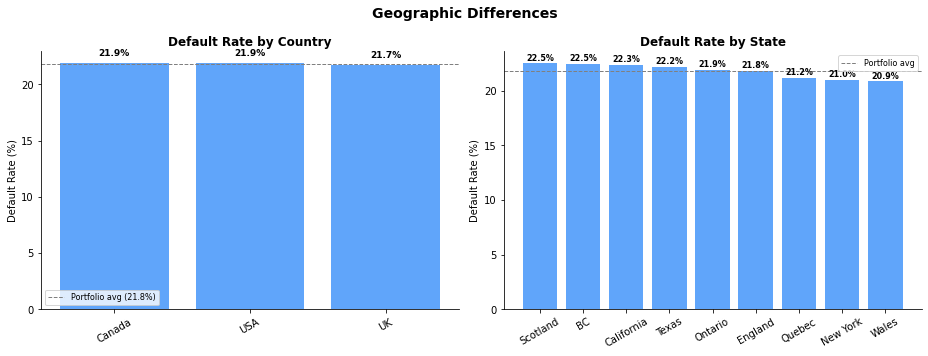

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Country level
plot_default_rate(credit_df, 'country', axes[0],
    'Default Rate by Country')

# State level
state_rate = default_rate(credit_df, 'state')['default_rate_%']
colors_state = [C_WARN if v>25 else '#60A5FA' if v>20 else C_SAFE for v in state_rate]
axes[1].bar(state_rate.index.astype(str), state_rate.values, color=colors_state)
axes[1].axhline(21.8, color='gray', linestyle='--', linewidth=1, label='Portfolio avg')
for b, v in zip(axes[1].patches, state_rate.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
            ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Default Rate by State', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

plt.suptitle('Geographic Differences', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Geography**: this is a crucial negative insight.
- No significant difference across countries: `USA` (21.86%), `UK` (21.73%), and `Canada` (21.86%) — a spread of only 0.13%. 

- No concentration at the state level either: The distribution across states/cities is very even. No state stands out as an outlier compared to the portfolio average. This indicates a geographically well-diversified portfolio.

**Business Implication**

(1) No need for country-specific underwriting policies — reduces operational complexity.

(2) Portfolio is geographically well-diversified — no geographic concentration risk.

(3) Exclude country/state/city from risk models — reduces the number of features and minimizes overfitting.

**Action**: Remove country, state, and city variables from all risk models and underwriting rules. Confirm with the Compliance team that geographic discrimination is not a driver of default policies.

### Q7. Which loan grades and terms are safer vs riskier?

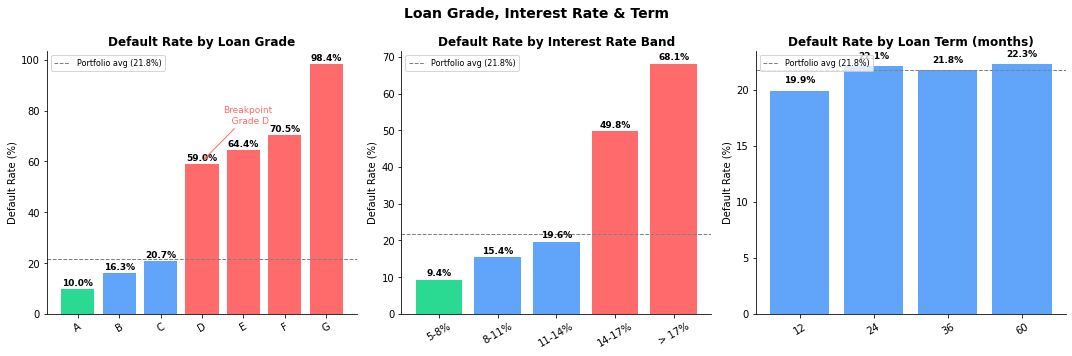

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loan grade — strong expected signal
plot_default_rate(credit_df, 'loan_grade', axes[0],
    'Default Rate by Loan Grade',
    order=['A','B','C','D','E','F','G'])

axes[0].annotate('Breakpoint\n   Grade D',
    xy=(3, 60), xytext=(3.5, 75),
    fontsize=9, color=C_WARN,
    arrowprops=dict(arrowstyle='->', color=C_WARN))

# Interest rate band
plot_default_rate(credit_df, 'rate_band', axes[1],
    'Default Rate by Interest Rate Band',
    order=['5-8%','8-11%','11-14%','14-17%','> 17%'])

# Loan term
plot_default_rate(credit_df, 'loan_term_months', axes[2],
    'Default Rate by Loan Term (months)',
    order=[12, 24, 36, 60])

plt.suptitle('Loan Grade, Interest Rate & Term', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Loan grade** is the categorical variable with the strongest predictive power, whereas **loan term** is a weak signal.
- `Loan grade D` marks a distinct dividing point: `A` (9.96%) → `B` (16.28%) → `C` (20.74%) → `D` (59.03%) → `E` (64.42%) → `F` (70.54%) → `G` (98.44%). The jump from grade C to D is nearly threefold—this is the most critical threshold in the entire analysis. `Grades A–C` fall within a manageable range, while `grades D–G` represent a zone of extremely high risk.

- **Interest rate**: Default rates range from 9.35% (for interest rates of 5–8%) to 68.11% (for rates above 17%). If the rate exceeds 14%, exercise caution during the application review process and evaluate the loan application in conjunction with the applicant's financial capacity.

- **Loan term** is a weak signal: `12 months` (19.94%) → `24 months` (22.10%) → `36 months` (21.76%) → `60 months` (22.34%). The spread is only about 2.4%—there is no monotonic trend (consistently increasing or decreasing), and it offers no specific actionable insight. Loan term does not predict default probability because borrowers with strong incomes may still choose longer terms to lower their monthly installment amounts.

**Business implication: Loan grade** is the strongest predictor in the entire dataset (88.5 pp spread) — ahead of interest rate band (58.7 pp), LTI (34.7 pp), and income band (34.1 pp). **Income** is a critical risk modifier but ranks fourth by discriminatory power, not first. Combining two variables—low income and a rating of D or lower—results in a default rate exceeding 75%. This combination necessitates a mandatory, immediate hard rule. **Interest rates** serve as an early warning signal; a rate above 14% indicates the bank has already priced in elevated risk — this should trigger a mandatory cross-check with **Grade** and **LTI** before approval proceeds, not an automatic rejection.

**Action:** For ratings of D or lower, mandate manual underwriting or automatic rejection. **Loan term** should be excluded from the risk model — it adds noise rather than signal (only 2.4 pp spread, no monotonic trend). **Interest rate**, however, is retained in the risk scorecard as a confirmatory signal: a rate above 14% indicates the bank has already priced in elevated risk, making it a valid co-indicator rather than a causal driver. Its role is to reinforce grade-based risk classification, not to substitute for it.

## MULTIVARIATE — Cross-tab & Interaction Effects
### Q8. Can we identify Safe vs Risky borrower groups?

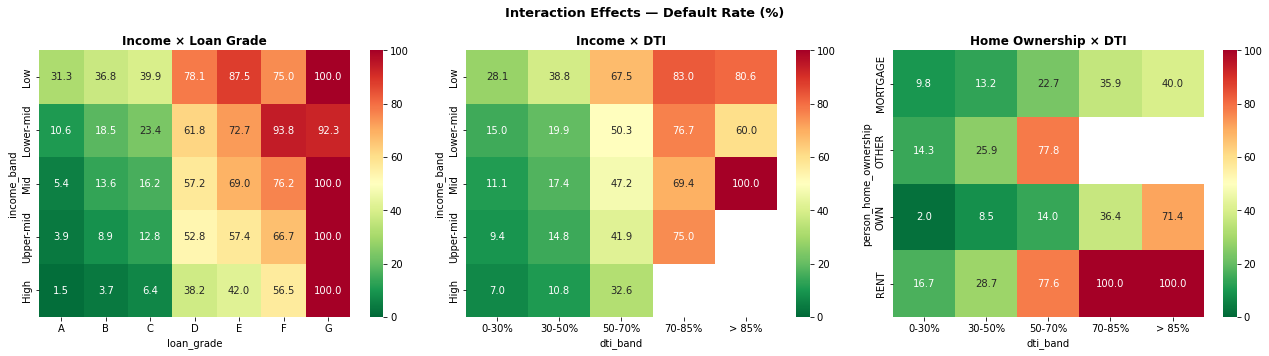

In [15]:
credit_df['default_flag'] = (credit_df['loan_status'] == 'Default').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (idx, col), title in zip(
    axes,
    [('income_band', 'loan_grade'),
     ('income_band', 'dti_band'),
     ('person_home_ownership', 'dti_band')],
    ['Income × Loan Grade', 'Income × DTI', 'Home Ownership × DTI']
):
    pivot = pd.pivot_table(credit_df, values='default_flag',
                            index=idx, columns=col,
                            aggfunc='mean') * 100
    sns.heatmap(pivot.round(1), annot=True, fmt='.1f',
                cmap='RdYlGn_r', ax=ax, vmin=0, vmax=100)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Interaction Effects — Default Rate (%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- Income × Loan Grade: 
    - Across all income groups, the default rate spikes sharply when the Grade shifts from C to D—representing the most critical inflection point in the entire portfolio. For the low-income group, the rate jumps from 39.9% to 78.1% (+38.2 percentage points), while for the high-income group, it rises from 6.4% to 38.2% (+31.8 percentage points). The Grade D threshold constitutes a "hard boundary" that must be clearly reflected in approval policies; it should not be treated linearly.
    - Income significantly reduces risk for Grades A–C but has almost no effect for Grades F–G. Grade G exhibits a 100% default rate across all income brackets from "Mid" upwards—meaning that regardless of the customer's earnings, a Grade G classification guarantees a default. Applications classified as Grade G should be automatically rejected without considering any other variables.
    - The true "safe zone": Upper-mid income + Grades A–B (3.9%–8.9%) and High income + Grades A–C (1.5%–6.4%)—this is the prime segment to prioritize for retention and cross-selling.
    - The danger zone: Low income + Grades E–G (87.5%–100%) represents the area marked in the deepest red. Lending should be avoided here under any circumstances, as expected losses far exceed potential interest income.

- Income × DTI: 
    - `The 50–70% DTI range` marks a critical tipping point: Across most income groups, the Default Rate surges once DTI exceeds 50%. For low-income earners, the rate jumps from 28.1% to 38.8%, then to 67.5% as DTI hits the 50–70% range; for middle-income earners, it rises from 11.1% to 17.4% and then to 47.2%. This threshold should serve as a "red flag" in credit scoring systems.

    - `The DTI >85%` is not always the worst-case scenario: An interesting anomaly appears here—low-income borrowers with a `DTI >85%` show a Default Rate of 80.6%, which is lower than the 83.0% observed in the `70–85% band`. Similarly, the DR for `lower-middle` borrowers with a `DTI >85%` (60.0%) is lower than that of the `70–85% group` (76.7%). A possible explanation is that individuals with extremely high DTI (>85%) often undergo stricter screening during approval, resulting in a cohort of higher actual credit quality compared to those just below that threshold.

    - High-income earners are "immune" when DTI is low: `The High-income group` with a DTI of `0–30%` shows a Default Rate of only 7.0%, while the `30–50%` range shows 10.8%—making these the most ideal segments. However, `high-income` earners with a `DTI >50%` (32.6%) still significantly exceed the portfolio average, demonstrating that high income does not offer protection against excessive debt.
    
- Home Ownership × DTI:
    - `The MORTGAGE group` is the absolute safest: regardless of the DTI level, this group consistently shows the lowest Default Rate within its column—ranging from 9.8% `low DTI` to 40.0% `DTI >85%`. Mortgage holders are servicing home loans; they possess collateral, have stable incomes pre-verified by banks, and face a strong incentive to avoid default to prevent losing their homes.

    - `The OWN group` is the safest when DTI is low: `the OWN + DTI 0–30% segment` shows a rate of just 2.0%—the lowest across the entire heatmap. However, `the OWN + DTI >85% segment` surges to 71.4%—higher than the `MORTGAGE group` in the same band. This suggests that homeowners without mortgages but with high DTI ratios are severely over-leveraged; they lack further assets to mobilize and have exhausted their cash flow.

    - `The RENT group` is the riskiest and exhibits the strongest non-linear behavior: `the RENT + DTI 70–85% and >85% segments` both show a DR of 100%—meaning no one in these cohorts was able to repay their debt. Renters lack accumulated assets and carry debt burdens that consume a large portion of their income, making them the most financially vulnerable group in the face of any income shock.

    - `The OTHER group` is the most enigmatic: `the OTHER + DTI 50–70% segment` shows a DR of 77.8%—an unusually high figure compared to other groups in the same DTI band. `The "Other" group` typically consists of individuals living with others, in informal rental arrangements, or in unstable housing situations—lacking both assets and residential stability. Further analysis of `the OTHER group`'s composition is required before including it in the model as a standalone category.

### Construct a risk score based on the key features analyzed above

In [16]:
def score_loan_grade(grade):
    """Max 30 pts. Non-linear at C->D: DR jumps 20.7% -> 59% (near-3x).
    C->D point gap = 18 pts vs B->C gap = 7 pts, reflecting the DR cliff.
    Grades E/F/G intentionally exceed 30-pt budget to enforce hard penalty."""
    mapping = {'A': 0, 'B': 5, 'C': 12, 'D': 30, 'E': 36, 'F': 42, 'G': 50}
    return mapping.get(str(grade), 30)

def score_rate_band(band):
    """Max 20 pts. DR jump at 14% mirrors LTI jump at 30%: both mark affordability cliff.
    Adds independent signal for mis-priced loans (e.g., Grade C at >17% interest)."""
    mapping = {'5-8%': 0, '8-11%': 5, '11-14%': 10, '14-17%': 18, '> 17%': 20}
    return mapping.get(str(band), 10)

def score_lti_band(band):
    """Max 15 pts. Single 53-pp cliff at 30% threshold -> point jump mirrors data cliff.
    Above 50%, DR plateaus at ~78-79%; score also plateaus (13 -> 15, only +2)."""
    mapping = {'0-30%': 0, '30-50%': 10, '50-70%': 13, '70-85%': 15, '> 85%': 15}
    return mapping.get(str(band), 8)

def score_income_band(band):
    """Max 15 pts. Clean monotonic gradient — equal steps reflect equal DR steps."""
    mapping = {'Low': 15, 'Lower-mid': 12, 'Mid': 8, 'Upper-mid': 4, 'High': 0}
    return mapping.get(str(band), 8)

def score_dti_band(band):
    """Max 10 pts. Two-step jump: safe at <50%, warning at 50-70%, danger at >70%.
    Smaller budget than LTI because DTI spread (30.9) < LTI spread (34.7)."""
    mapping = {'0-30%': 0, '30-50%': 2, '50-70%': 7, '70-85%': 10, '> 85%': 10}
    return mapping.get(str(band), 5)

def score_home_ownership(status):
    """Max 8 pts. OWN=asset anchor (DR 7.5%), RENT=no asset + highest DR (31.6%)."""
    mapping = {'OWN': 0, 'MORTGAGE': 2, 'OTHER': 6, 'RENT': 8}
    return mapping.get(str(status), 5)

def score_prior_default(flag):
    """Max 8 pts. Binary — most actionable signal (2.05x multiplier).
    Must be checked BEFORE any other underwriting step in the rule engine."""
    return {'Y': 8, 'N': 0}.get(str(flag), 0)

def score_loan_intent(intent):
    """Max 4 pts. Weakest driver (13.8 dpt spread) — acts as modifier, not gate.
    Defensive borrowing (Debt Consolidation, Medical) = highest modifier."""
    mapping = {
        'VENTURE': 0, 'EDUCATION': 1,
        'PERSONAL': 2, 'HOMEIMPROVEMENT': 3,
        'MEDICAL': 4, 'DEBTCONSOLIDATION': 4
    }
    return mapping.get(str(intent).upper(), 2)

def compute_risk_score(row):
    return (
        score_loan_grade(row.get('loan_grade'))
        + score_rate_band(row.get('rate_band'))
        + score_lti_band(row.get('lti_band'))
        + score_income_band(row.get('income_band'))
        + score_dti_band(row.get('dti_band'))
        + score_home_ownership(row.get('person_home_ownership'))
        + score_prior_default(row.get('cb_person_default_on_file'))
        + score_loan_intent(row.get('loan_intent'))
    )

def assign_segment(score):
    """Thresholds set at natural breaks in score distribution (verified post-hoc):
    Safe     <= 12:  Grade A-B + good leverage. Target DR < 5%
    Moderate <= 28:  Grade B-C, manageable leverage. Standard approval zone.
    Risky    <= 45:  Grade C-D boundary or one major risk flag. Enhanced review.
    High Risky > 45: Grade D+ or multiple compounding flags. Decline / collateral."""
    if score <= 12:   return 'Safe'
    elif score <= 28: return 'Moderate'
    elif score <= 45: return 'Risky'
    else:             return 'High Risky'

# ── Build score table ──────────────────────────────────────────────────────
risk_score_df = credit_df[[
    'client_ID', 'income_band', 'loan_grade', 'rate_band',
    'dti_band', 'lti_band', 'person_home_ownership',
    'cb_person_default_on_file', 'loan_intent'
]].copy()

risk_score_df['income_score']        = risk_score_df['income_band'].apply(score_income_band)
risk_score_df['grade_score']         = risk_score_df['loan_grade'].apply(score_loan_grade)
risk_score_df['rate_score']          = risk_score_df['rate_band'].apply(score_rate_band)
risk_score_df['lti_score']           = risk_score_df['lti_band'].apply(score_lti_band)
risk_score_df['dti_score']           = risk_score_df['dti_band'].apply(score_dti_band)
risk_score_df['home_score']          = risk_score_df['person_home_ownership'].apply(score_home_ownership)
risk_score_df['prior_default_score'] = risk_score_df['cb_person_default_on_file'].apply(score_prior_default)
risk_score_df['intent_score']        = risk_score_df['loan_intent'].apply(score_loan_intent)

risk_score_df['risk_score']   = risk_score_df.apply(compute_risk_score, axis=1)
risk_score_df['risk_segment'] = risk_score_df['risk_score'].apply(assign_segment)

print("Score distribution:")
print(risk_score_df['risk_score'].describe().round(1))
print()
print("Segment distribution:")
print(risk_score_df['risk_segment'].value_counts(normalize=True).mul(100).round(1))


Score distribution:
count    32574.0
mean        35.8
std         21.6
min          0.0
25%         19.0
50%         32.0
75%         48.0
max        115.0
Name: risk_score, dtype: float64

Segment distribution:
risk_segment
Moderate      32.7
High Risky    28.1
Risky         27.3
Safe          11.9
Name: proportion, dtype: float64


In [17]:
credit_df = credit_df.merge(risk_score_df[['client_ID', 'risk_score', 'risk_segment']], on='client_ID', how='left')
credit_df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,income_band,emp_band,loan_amnt_band,dti_band,lti_band,rate_band,delinq_band,default_flag,risk_score,risk_segment
0,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,Non-default,...,Low,3-5yr,0-5K,0-30%,0-30%,11-14%,3+,0,31,Risky
1,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,Default,...,Low,0-2yr,5-10K,> 85%,50-70%,11-14%,0 (Clean),1,66,High Risky
2,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,Default,...,Upper-mid,3-5yr,> 20K,50-70%,50-70%,14-17%,0 (Clean),1,66,High Risky
3,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,Default,...,Mid,6-10yr,> 20K,> 85%,50-70%,14-17%,0 (Clean),1,81,High Risky
4,CUST_00006,21,9900,OWN,2.0,VENTURE,A,2500,7.14,Default,...,Low,0-2yr,0-5K,30-50%,0-30%,5-8%,0 (Clean),1,17,Moderate


Risk Segment Validation:
loan_status   Default  Non-default  default_rate_%
risk_segment                                      
High Risky       4826         4333           52.69
Risky            1601         7285           18.02
Moderate          626        10021            5.88
Safe               54         3828            1.39


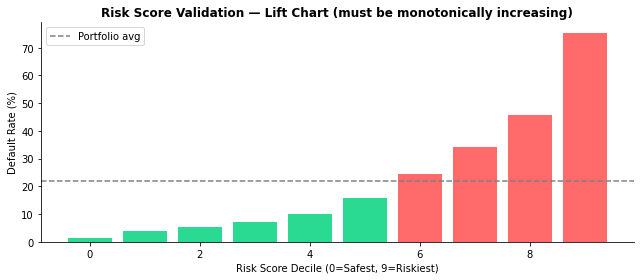


Risk Score — AUC: 0.843 | Gini: 0.686


In [18]:
# ── VALIDATE: Rank ordering check ────────────────────────
# A good score requires the default rate to increase monotonically across segments.
validation = default_rate(credit_df, 'risk_segment')
print("Risk Segment Validation:")
print(validation[['Default', 'Non-default', 'default_rate_%']])

# ── VALIDATE: Lift table (decile analysis) ───────────────
credit_df['score_decile'] = pd.qcut(credit_df['risk_score'], q=10, labels=False, duplicates='drop')
lift = credit_df.groupby('score_decile')['default_flag'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lift.index, lift.values, color=[C_SAFE if v<20 else C_WARN for v in lift])
ax.axhline(21.8, color='gray', ls='--', label='Portfolio avg')
ax.set_xlabel('Risk Score Decile (0=Safest, 9=Riskiest)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Risk Score Validation — Lift Chart (must be monotonically increasing)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Gini coefficient
from sklearn.metrics import roc_auc_score
auc  = roc_auc_score(credit_df['default_flag'], credit_df['risk_score'])
gini = 2*auc - 1
print(f"\nRisk Score — AUC: {auc:.3f} | Gini: {gini:.3f}")
# Gini > 0.3 = acceptable | > 0.5 = good | > 0.7 = excellent

## CONCLUSION & RECOMMENDATIONS
### Key Insights
**- Loan Grade is the strongest risk boundary**

Loan Grade is the strongest categorical risk driver in the portfolio. Default Rate increases sharply from **20.7% for Grade C to 59.0% for Grade D**, with Grades D–G reaching **59–98%**.

**Business implication**: Grade D–G represents a critical risk zone where standard approval rules may no longer be appropriate. These borrowers require significantly tighter underwriting controls.

**- Borrower affordability is a critical risk driver**

Affordability has a strong relationship with default risk. Default Rate increases sharply when **LTI exceeds 30%**, reaching **68.2%**, while lower-income borrowers show substantially higher risk (**43.3% vs. 9.1%** for high-income borrowers).

However, income alone cannot offset poor credit quality — for example, **High-income borrowers with Grade D still show a 38.2% Default Rate**.

**Business implication**: Income should be treated as a risk modifier rather than a rescue factor, while LTI >30% should be considered a key underwriting threshold.

**- Prior default and borrower characteristics enable targeted risk controls**

Borrowers with a **prior default** show approximately **2.05× higher default risk**, making this one of the most actionable signals available during underwriting.

The interaction between borrower characteristics reveals extreme risk concentrations in specific sub-zones: **RENT + DTI >70%** shows 77–100% default rate in the interaction heatmap — note this is the rate within that specific cell, distinct from the overall **High Risky segment** DR of 52.69%.

**Business implication**: The bank can use these high-risk combinations to create targeted underwriting rules rather than applying blanket rejection policies across the entire portfolio.

| Rule   | Risk Condition             | Recommended Action             | Rationale                                                                                               |
| ------ | -------------------------- | ------------------------------ | ------------------------------------------------------------------------------------------------------- |
| **R1** | **Grade D–G AND LTI ≥30%** | 🔴 **Auto-decline**            | Default Rate reaches **66–100%** in the identified high-risk zone.                                      |
| **R2** | **RENT AND DTI >70%**      | 🔴 **Auto-decline**            | Observed Default Rate reaches **77–100%** across interaction cells.                                     |
| **R3** | **Prior default = Yes**    | 🟠 **Mandatory manual review** | Prior default is associated with approximately **2.05× higher risk**.                                   |
| **R4** | **Interest rate >17%**     | 🟠 **Re-validate loan grade**  | High-rate loans show **50–68% Default Rate**, suggesting the need to validate risk grading and pricing. |

**Expected impact**

These rules focus underwriting resources on the **highest-concentration risk zones** while avoiding blanket rejection of the broader portfolio.

The objective is to move from a one-size-fits-all approval process toward **risk-based underwriting**, where the level of control increases with borrower risk.

### Risk Score — AUC: 0.843 · Gini: 0.686 · 4 clearly separated segments

**Segment performance**:

| Segment | Target DR | Observed DR | Policy |
|---|---|---|---|
| 🟢 Safe | < 5% | ~1.39% | Fast-track approval, preferred pricing |
| 🔵 Moderate |  5–10% | ~5.88% | Standard approval, standard pricing |
| 🟠 Risky | 10–20% | ~18.02% | Enhanced verification, cap LTI at 25% |
| 🔴 High Risky | > 20% | ~52.69% | Manual review + collateral / co-signer |

*Note: Target DR reflects standard industry benchmarks for prime/near-prime/subprime/distressed lending segments, not derived from this dataset*

**Business Implication**:

- Clear risk differentiation: Default rates rise sharply from 1.39% in Safe to 52.69% in **High Risk segments**.
- Risk-based underwriting: Approval requirements should become progressively stricter as borrower risk increases.
- Balanced lending strategy: Fast-track low-risk borrowers while applying tighter controls to high-risk segments to balance growth and credit risk.

In [19]:
credit_df.to_csv("final_report.csv", index=False, encoding='utf-8')

# Build a Machine Learning model
## From Exploratory Analysis to Predictive Modeling
The exploratory analysis identified several key drivers of default risk, including **Loan Grade, LTI, Income, DTI, Prior Default, and Interest Rate**.

To move from understanding **what drives default risk** to predicting **which individual borrowers are likely to default**, the next stage is to build a **Machine Learning classification model** for **loan_status**.

The modeling workflow will focus on:

**Feature Selection → Preprocessing → Model Training → Evaluation → Feature Importance → Risk-Based Lending**

### Feature Selection & Preprocessing

In [20]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, OrdinalEncoder
from sklearn.metrics         import roc_auc_score, classification_report, roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [21]:
ML_df = credit_df[['loan_grade', 'loan_int_rate', 'loan_to_income_ratio', 'debt_to_income_ratio', 'person_income', 
                  'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'default_flag']]

In [22]:
credit_df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'gender', 'marital_status',
       'education_level', 'country', 'state', 'city', 'city_latitude',
       'city_longitude', 'employment_type', 'loan_term_months',
       'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio',
       'open_accounts', 'credit_utilization_ratio', 'past_delinquencies',
       'age_band', 'income_band', 'emp_band', 'loan_amnt_band', 'dti_band',
       'lti_band', 'rate_band', 'delinq_band', 'default_flag', 'risk_score',
       'risk_segment', 'score_decile'],
      dtype='object')

In [23]:
ML_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loan_grade                 32574 non-null  object 
 1   loan_int_rate              32574 non-null  float64
 2   loan_to_income_ratio       32574 non-null  float64
 3   debt_to_income_ratio       32574 non-null  float64
 4   person_income              32574 non-null  int64  
 5   person_home_ownership      32574 non-null  object 
 6   cb_person_default_on_file  32574 non-null  object 
 7   loan_intent                32574 non-null  object 
 8   default_flag               32574 non-null  int32  
dtypes: float64(3), int32(1), int64(1), object(4)
memory usage: 2.1+ MB


In [24]:
ML_df.head()

,loan_grade,loan_int_rate,loan_to_income_ratio,debt_to_income_ratio,person_income,person_home_ownership,cb_person_default_on_file,loan_intent,default_flag
0,B,11.14,0.104167,0.271646,9600,OWN,N,EDUCATION,0
1,C,12.87,0.572917,0.860469,9600,MORTGAGE,N,MEDICAL,1
2,C,15.23,0.534351,0.643592,65500,RENT,N,MEDICAL,1
3,C,14.27,0.643382,0.930628,54400,RENT,Y,MEDICAL,1
4,A,7.14,0.252525,0.475933,9900,OWN,N,VENTURE,1


In [25]:
X = ML_df.iloc[:,:-1]
y = ML_df.iloc[:,-1] # 1 = Default, 0 = Non-default

# Stratified: preserves 21.8% default rate in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42, stratify=y)
print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Test  default rate: {y_test.mean():.1%}")

Train: 26,059 rows  |  Test: 6,515 rows
Train default rate: 21.8%
Test  default rate: 21.8%


In [26]:
# StandardScaler
scaler = StandardScaler()
numeric_features  = ['loan_int_rate', 'loan_to_income_ratio','debt_to_income_ratio', 'person_income']
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])
# OrdinalEncoder
category_features = ['loan_grade', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent']
encoder = OrdinalEncoder()
X_train[category_features] = encoder.fit_transform(X_train[category_features])
X_test[category_features]  = encoder.transform(X_test[category_features])

### Model Training 
#### Baseline: Logistic Regression

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_predict = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)
lr_gini = 2 * lr_auc - 1

print(f"AUC : {lr_auc:.3f}")
print(f"Gini: {lr_gini:.3f}")
print(classification_report(y_test, lr_predict))

AUC : 0.841
Gini: 0.682
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      5094
           1       0.75      0.45      0.56      1421

    accuracy                           0.85      6515
   macro avg       0.80      0.70      0.73      6515
weighted avg       0.84      0.85      0.83      6515



#### RandomForest

In [28]:
rf_model = RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            max_features=2,
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        )
rf_model.fit(X_train, y_train)

rf_predict  = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_prob)
rf_gini  = 2 * rf_auc - 1

print(f"AUC : {rf_auc:.3f}")
print(f"Gini: {rf_gini:.3f}")
print(classification_report(y_test, rf_predict))

AUC : 0.886
Gini: 0.772
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      5094
           1       0.84      0.61      0.71      1421

    accuracy                           0.89      6515
   macro avg       0.87      0.79      0.82      6515
weighted avg       0.89      0.89      0.88      6515



#### Main Model: XGBoost

In [29]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_w  = neg / pos  # ≈ 3.58

xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,     
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight     = scale_w,
    eval_metric       = 'auc',
    early_stopping_rounds = 30,
    random_state      = 42,
    verbosity         = 0
)

xgb_model.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = False)

xgb_predict  = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_prob)
xgb_gini  = 2 * xgb_auc - 1

print(f"AUC : {xgb_auc:.3f}")
print(f"Gini: {xgb_gini:.3f}")
print(classification_report(y_test, xgb_predict))

AUC : 0.940
Gini: 0.879
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      5094
           1       0.77      0.78      0.78      1421

    accuracy                           0.90      6515
   macro avg       0.85      0.86      0.86      6515
weighted avg       0.90      0.90      0.90      6515



In [30]:
# ── Bảng so sánh tổng hợp ─────────────────────────────────────
print("══ Model Comparison ══════════════════════════════════")
print(f"{'Model':<22} {'AUC':>6}  {'Gini':>6}  {'Note'}")
print("─" * 60)
print(f"{'Heuristic Scorecard':<22} {auc:>6,.3f}  {gini:>6,.3f}  baseline (hand-crafted)")
print(f"{'Logistic Regression':<22} {lr_auc:>6.3f}  {lr_gini:>6.3f}  interpretable, Basel OK")
print(f"{'Random Forest':<22} {rf_auc:>6.3f}  {rf_gini:>6.3f}  ensemble, non-linear")
print(f"{'XGBoost':<22} {xgb_auc:>6.3f}  {xgb_gini:>6.3f}  best expected performance")

══ Model Comparison ══════════════════════════════════
Model                     AUC    Gini  Note
────────────────────────────────────────────────────────────
Heuristic Scorecard     0.843   0.686  baseline (hand-crafted)
Logistic Regression     0.841   0.682  interpretable, Basel OK
Random Forest           0.886   0.772  ensemble, non-linear
XGBoost                 0.940   0.879  best expected performance


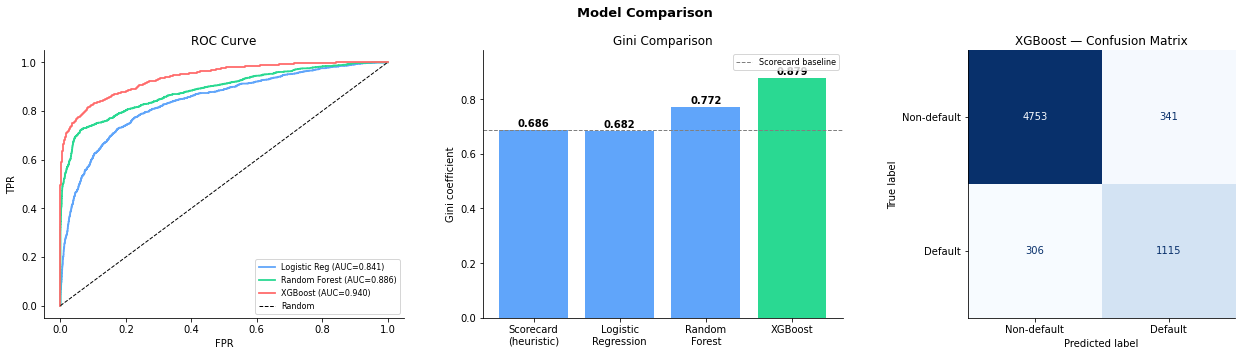

In [31]:
# ── ROC Curve 3 model ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison', fontweight='bold', fontsize=13)

ax = axes[0]
for prob, name, color in [
    (lr_prob,  f'Logistic Reg (AUC={lr_auc:.3f})',  '#60A5FA'),
    (rf_prob,  f'Random Forest (AUC={rf_auc:.3f})',  C_SAFE),
    (xgb_prob, f'XGBoost (AUC={xgb_auc:.3f})',       C_WARN),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=1.8, label=name, color=color)
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
ax.legend(fontsize=8)

# ── Gini bar chart ─────────────────────────────────────────────
ax = axes[1]
models  = ['Scorecard\n(heuristic)', 'Logistic\nRegression', 'Random\nForest', 'XGBoost']
ginis   = [0.686, lr_gini, rf_gini, xgb_gini]
colors  = [C_SAFE if g == max(ginis) else '#60A5FA' for g in ginis]
bars    = ax.bar(models, ginis, color=colors)
ax.axhline(0.686, color='gray', ls='--', lw=1, label='Scorecard baseline')
for b, v in zip(bars, ginis):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set(ylabel='Gini coefficient', title='Gini Comparison',
       ylim=[0, max(ginis)+0.1])
ax.legend(fontsize=8)

# ── Confusion matrices ─────────────────────────────────────────
ax = axes[2]
# Show XGBoost (best model) confusion matrix
cm = confusion_matrix(y_test, xgb_predict)
ConfusionMatrixDisplay(cm, display_labels=['Non-default','Default']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Confusion Matrix')

plt.tight_layout()
plt.show()

In [32]:
# ── Classification reports ─────────────────────────────────────
for name, pred in [('Logistic Regression', lr_predict),
                   ('Random Forest',        rf_predict),
                   ('XGBoost',              xgb_predict)]:
    print(f"\n── {name} ──────────────────────────────────────────")
    print(classification_report(y_test, pred,
                                target_names=['Non-default','Default']))


── Logistic Regression ──────────────────────────────────────────
              precision    recall  f1-score   support

 Non-default       0.86      0.96      0.91      5094
     Default       0.75      0.45      0.56      1421

    accuracy                           0.85      6515
   macro avg       0.80      0.70      0.73      6515
weighted avg       0.84      0.85      0.83      6515


── Random Forest ──────────────────────────────────────────
              precision    recall  f1-score   support

 Non-default       0.90      0.97      0.93      5094
     Default       0.84      0.61      0.71      1421

    accuracy                           0.89      6515
   macro avg       0.87      0.79      0.82      6515
weighted avg       0.89      0.89      0.88      6515


── XGBoost ──────────────────────────────────────────
              precision    recall  f1-score   support

 Non-default       0.94      0.93      0.94      5094
     Default       0.77      0.78      0.78      1421


**1. XGBoost delivers the strongest predictive performance**

XGBoost achieved AUC 0.940 / Gini 0.879, outperforming both Logistic Regression (0.841) and Random Forest (0.886).

**2. Machine Learning substantially improves default detection**

At the default threshold of 0.5, XGBoost captures 78% of actual defaults vs 45% for Logistic Regression. However, AUC comparison (0.939 vs 0.841) is the more reliable metric — it evaluates performance across all thresholds rather than at a single cut-off point.

**3. Non-linear modeling adds value beyond the heuristic scorecard**

XGBoost improved AUC from 0.843 with the hand-crafted scorecard to 0.940, suggesting that default risk contains non-linear patterns that simple rule-based scoring does not fully capture.

**4. Random Forest underperformance**

Random Forest (AUC 0.886) underperforms XGBoost (AUC 0.939) primarily because boosting (XGBoost) iteratively corrects errors from previous trees, while bagging (Random Forest) averages independent trees. With max_features=2 and max_depth=4, each Random Forest tree has limited capacity — increasing max_features='sqrt' and max_depth=6 would likely close part of the gap. The fundamental advantage of XGBoost on tabular data with strong categorical signals (like loan_grade) is well-documented in literature.